<a href="https://colab.research.google.com/github/DhruviPunamia15/Dhruvi-Punamia_LP_Synapse26/blob/week1_ML/Copy_of_Synapse_Task1A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Synapse Week One**

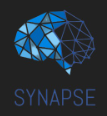

Last week, we focused on building the foundations needed to get started with Machine Learning. We explored Python and learned how to work with and understand data through Exploratory Data Analysis (EDA).

Now, it is time to take the next step and use that knowledge to build our first Machine Learning model. In this task, we will explore Regression, a type of supervised learning where the goal is to predict a continuous numerical value.

We will begin by exploring an insurance dataset and using EDA to understand the relationships between its different attributes and the insurance charges. Once we understand our data, we will prepare it for Machine Learning and build a Linear Regression model to predict the incurred charges.

But we won't stop at simply using a library. We will also take a look under the hood and implement Linear Regression from scratch, giving us a better understanding of what happens when a model is trained.

Resources and comments are provided throughout the notebook. Go through them carefully, understand the concepts, and then get coding.

Let's get started.

Supervised vs Unsupervised vs Reinforcement Learning:

https://www.simplilearn.com/tutorials/machine-learning-tutorial/types-of-machine-learning

Regression vs Classification :

https://www.analyticsvidhya.com/blog/2023/05/regression-vs-classification/ (Might be a little wordy)

https://www.youtube.com/watch?v=1NBwM5tavTk&ab_channel=IntuitiveML
(A very quick video)

https://www.geeksforgeeks.org/ml-classification-vs-regression/
(Short and Sweet)

Machine Learning for Everyone (Read till 1.1):

https://vas3k.com/blog/machine_learning/

Overfitting and Underfitting [VERY IMPORTANT]
https://www.youtube.com/watch?v=T9NtOa-IITo

Lets import all the basic libraries.

In [ ]:
!pip install shap -q  #Will be used later on

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Regression

For regression we will use insurance dataset, which contains medical costs incurred
https://drive.google.com/file/d/1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ/view?usp=sharing

## Basic EDA

### Import dataset

In [ ]:

df=pd.read_csv("/content/drive/MyDrive/insurance.csv")

### Use the very first steps involved in EDA -> info, head and describe

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Now, plot a histogram to understand insurance charges *distribution*

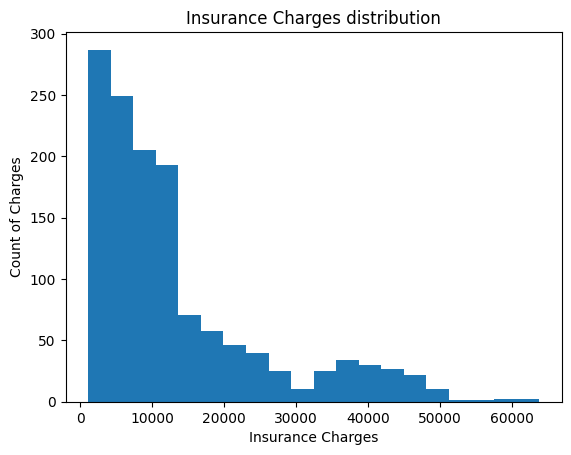

In [ ]:
plt.hist(df["charges"],bins=20)
plt.xlabel("Insurance Charges")
plt.ylabel("Count of Charges")
plt.title("Insurance Charges distribution")
plt.show()

### Plot a scatter plot between age and insurance charges

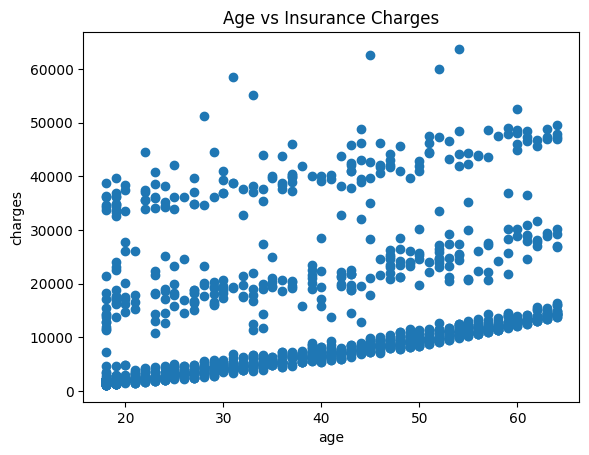

In [ ]:
plt.scatter(df["age"], df["charges"])
plt.xlabel("age")
plt.ylabel("charges")
plt.title("Age vs Insurance Charges")
plt.show()

### Similarly, plot scatterplots for no. of children and charges, and also for bmi and charges


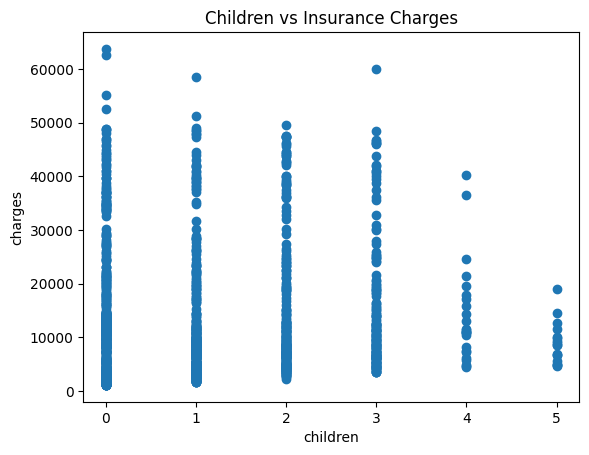

In [ ]:
plt.scatter(df["children"], df["charges"])
plt.xlabel("children")
plt.ylabel("charges")
plt.title("Children vs Insurance Charges")
plt.show()

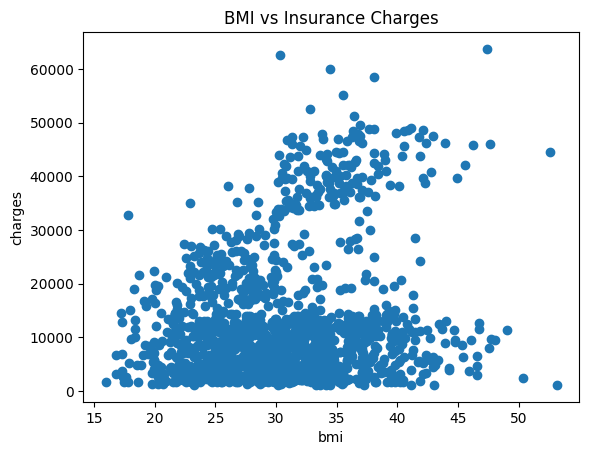

In [ ]:
plt.scatter(df["bmi"], df["charges"])
plt.xlabel("bmi")
plt.ylabel("charges")
plt.title("BMI vs Insurance Charges")
plt.show()

### Now, use boxplots to find correlation between Sex and Charges, between Smoker and charges, and also between region and charges

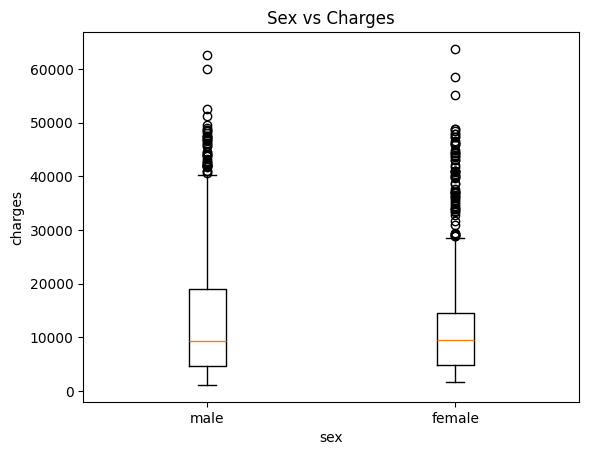

In [ ]:
plt.boxplot([df[df["sex"]=="male"]["charges"], df[df["sex"]=="female"]["charges"]], tick_labels=["male","female"])
plt.xlabel("sex")
plt.ylabel("charges")
plt.title("Sex vs Charges")
plt.show()

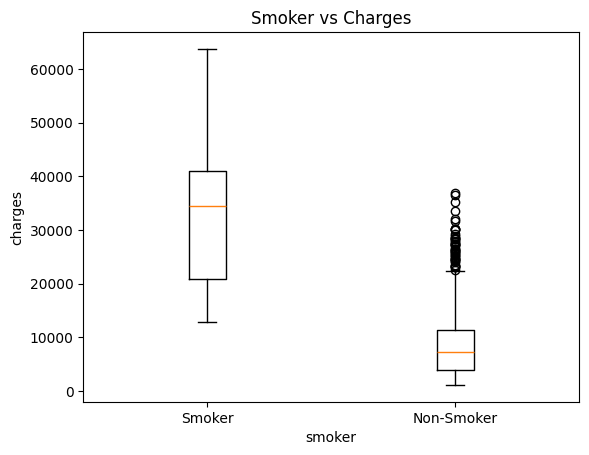

In [ ]:
plt.boxplot([df[df["smoker"]=="yes"]["charges"], df[df["smoker"]=="no"]["charges"]], tick_labels=["Smoker","Non-Smoker"])
plt.xlabel("smoker")
plt.ylabel("charges")
plt.title("Smoker vs Charges")
plt.show()

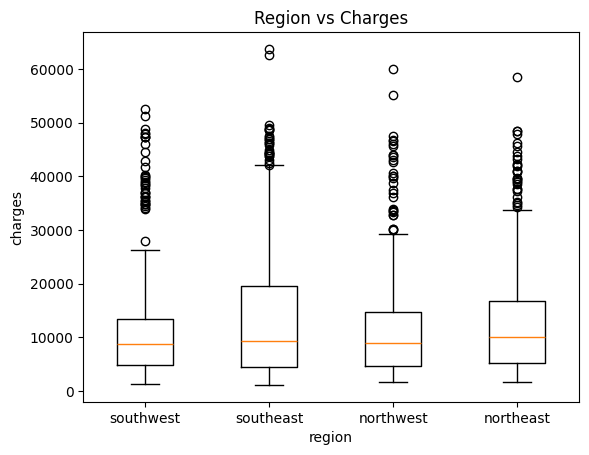

In [ ]:
regions = df["region"].unique()
plt.boxplot([df[df["region"]==r]["charges"] for r in regions], tick_labels=regions)
plt.xlabel("region")
plt.ylabel("charges")
plt.title("Region vs Charges")
plt.show()

##### Now, make a heatmap to understand correlation between all attributes

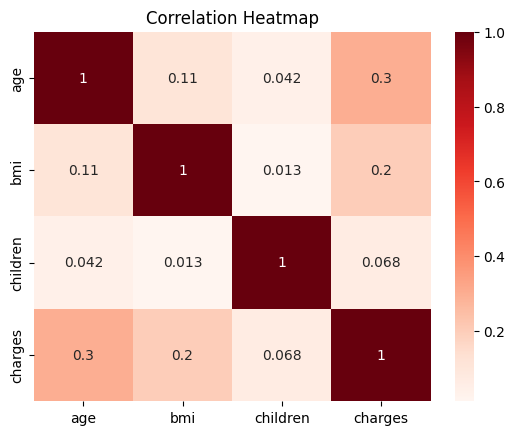

In [ ]:
sb.heatmap(df.corr(numeric_only=True), annot=True, cmap="Reds")
plt.title("Correlation Heatmap")
plt.show()

## Question: What do you infer from the above analysis🤔

From the above analysis we infered which parameters matter w.r.t the insurance charges before going on to building our model.We observed from these plots that age and bmi have a good effect on the insurance charges.Also a smoker have hugh charges compared to non-smokers.While,sex,children and region didn't show much influence on the charges.

### Now let's prep our data to perform Regression to predict the Incurred Charges

### Again do df.info() see how the datatype is

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### As you can see, sex, region and smoker attributes are of the object data type.
### So, convert them into numerical labels, using Label Encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

for col in ["sex", "smoker", "region"]:
    df[col] = le.fit_transform(df[col])

Do df.head() to see how your dataframe looks like after LabelEncoding

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Question: What does label encoder do? 🤔

The Label Encoder basically helped us convert colums with text values to numerical values.Since a ML model can't work with text,we used Label Encoder for the same conversion .

### Now that you already know about standardization and normalization (I hope🙃), implement normalization here here:


##### Import MinMaxScaler from sklearn and normalize the coloums - ['age','bmi', 'children', 'charges']



### Answer:

In [ ]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["age","bmi","children","charges"]] = scaler.fit_transform(df[["age","bmi","children","charges"]])



## Question: Why standardization is not needed here? 🤔



Comparing the both,Standardization would.ve worked if our columns had existing outliers.Also since usage of MinMaxScaler was mentioned we went with normalization which helped all features to the sacle of 0-1.

### Answer:

As we are going to predict Insurance Charges, let us make two sections: one containing only the 'charges', and the other containing all values except for 'charges'

In [ ]:
X = df.drop("charges", axis=1)
y = df["charges"]


### Train-Test Split

Implementation - https://www.youtube.com/watch?v=BUkqYGPnLZ8&ab_channel=ManifoldAILearning

### Now, while we need data to train our regression model, it is equally important to keep some data aside for testing the effectiveness of the aforementioned model. Thus the dataset as a whole is generally further divided into the training dataset and the testing dataset.

In order to implement this, import train_test_split function from scikit-learn.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Print the size and shape of each of the train/test splits (it should be in the ratio as per test_size parameter above, i.e in ratio of 0.3)

In [ ]:
print("X_train size:", X_train.shape)
print("X_test size:", X_test.shape)
print("y_train size:", y_train.shape)
print("y_test size:", y_test.shape)

X_train size: (936, 6)
X_test size: (402, 6)
y_train size: (936,)
y_test size: (402,)


### The data is now split into 2 datasets of size 70% and 30% of original dataset. Surprised? 😮

### We have preprocessed our DataFrame now we'll perform Regression on this Data

### First lets understand Linear Regression, watch this video carefully it will be helpfull later on :)

https://www.youtube.com/watch?v=7ArmBVF2dCs

### A quick article
https://www.analyticsvidhya.com/blog/2021/08/understanding-linear-regression-with-mathematical-insights/

In [ ]:
#train a model
from sklearn.linear_model import LinearRegression

regressor= LinearRegression()



In [ ]:
# fit the model on the training data, hint: use the fit method
regressor.fit(X_train, y_train)

LinearRegression()

#### The X_train and y_train dataframes have been used to train the model. Now we will use X_test and y_test to evaluate the efficiency of the model we have trained.

#### Use regressor.predict() on X_test and store it in a variable called "y_pred". Print type and size of the y_pred.

#### Size should be 402 if everything is correct. Yeh line confirm karna hai

In [ ]:
# make predictions on the test data
y_pred = regressor.predict(X_test)

print(type(y_pred))
print(y_pred.size)

<class 'numpy.ndarray'>
402


In [ ]:
# calculate the mean squared error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(mse)

0.008613205996999699


### Visualize the predictions, plot a scatter plot of y_test vs y_pred and also plot the best fit line

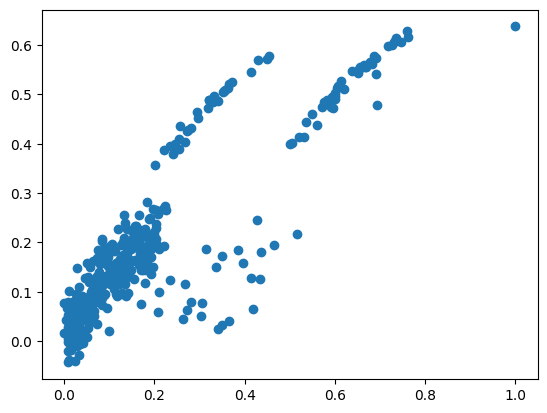

In [ ]:
plt.scatter(y_test, y_pred)

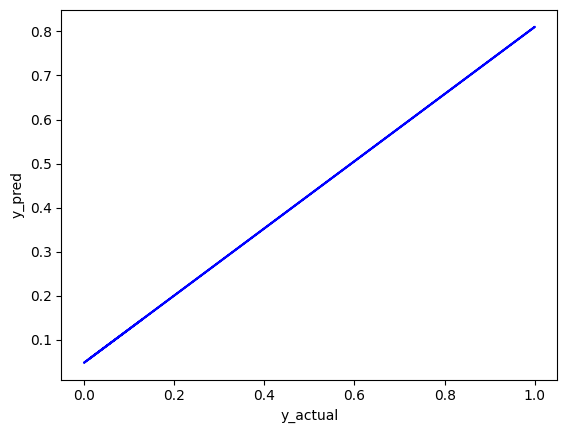

In [ ]:
m, c = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + c, color="blue")
plt.xlabel("y_actual")
plt.ylabel("y_pred")
plt.show()


# Now let's start the fun part 😃

### Have you ever wondered what happens when you call **'regressor.fit(X_train, y_train)'** ?

### To understand what's hapenning in .fit method we will be implementing Linear Regression from scratch.

In [ ]:
class LinearRegression() :

    def __init__( self, learning_rate, iterations ) :
        # initialize the learning rate and iterations provides by the user
        self.learning_rate = learning_rate

        self.iterations = iterations

    # Function for model training
    def fit( self, X, Y ) :

        # no_of_training_examples, no_of_features
        self.m, self.n=X.shape

        # what does self.m and self.n represent and why are they calculated?

        # self.m represents the no. of rows (samples) in training data, while self.n shows number of features in the training data
        # they are calculated
        # weight initialization
        self.W =np.zeros(self.n)

        self.b =0 # set this equal to 0

        self.X =X   # set this equal to X

        self.Y =Y # set this equal to Y


        # gradient descent learning
        for i in range(self.iterations) : # complete the range function

            self.update_weights()

        return self

    # Helper function to update weights in gradient descent
    def update_weights(self) :

        Y_pred = self.predict(self.X) # complete this line

        # calculate gradients
        dW = -(2 * (self.X.T).dot(self.Y - Y_pred)) / self.m  # dL/dW -> L = MSE = (y -ypred)^2/m
        db =-2 * np.sum(self.Y - Y_pred) / self.m

        # write the code to update the weights
        self.W =self.W - self.learning_rate * dW
        self.b =self.b - self.learning_rate * db

        return self


    def predict(self,X) :

        return X.dot(self.W) + self.b


In [ ]:
model = LinearRegression( iterations = 10000, learning_rate = 0.0015 )

model.fit(X_train, y_train)


## Question: What is this function actually doing? 🤔
#### Answer Here
<br>
We started by telling the model about the learning rate and iterations.Then initially the bias and weight is at zero.Then the charges are predicted using other columns and are compared with the actual values.After that the error is estimated to further adjust the parameters.After doing this through the iterations more accuratr predictions are made.

### Now predict the output for the test data

In [ ]:
y_pred = model.predict(X_test)

### Calculate the mean squared error


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(mse)

0.008786906117368229


### Plot a similar scatter plot as above


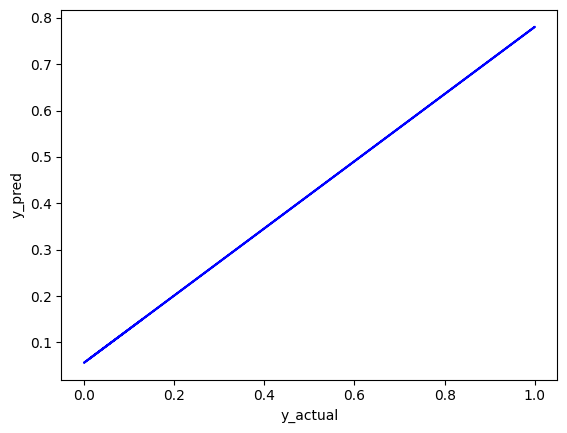

In [ ]:
m, c = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + c, color="blue")
plt.xlabel("y_actual")
plt.ylabel("y_pred")
plt.show()

How to Approach the Research Tasks :)

Guys, one important thing about how you should approach these tasks.

The links and videos provided are meant to be read/watched. Go through them, understand the concepts, and then write what you understood in your own words. You can also find your own resources — don't restrict yourself to the links we provide.

And please, don’t just GPT your way through the tasks. These are your foundational basics, so actually understand what you're doing. Try reading documentation, Stack Overflow discussions, technical articles, etc. These will become your best guides when you're learning ML independently.

The Research Task is compulsory and one of the most important parts of your learning, irrespective of what you do. Research is an engineer's way of learning — it's how you learn ML for what it actually is, rather than just learning how to write the code.

For the Research Task, research properly, understand what you find, and explain it in your own words. No implementation is required unless mentioned.

The best Research Task submission after every task will be featured on Synapse's LinkedIn with a tag, giving you an opportunity to connect with our alumni and seniors and grow your network.

So don't treat the Research Task as just another question to finish. Actually explore, understand, and learn from it :)

## Research Task: Underfitting & Overfitting

We’ve now built our first Linear Regression model. Before moving ahead, let’s understand an important problem that can affect any ML model: **Underfitting and Overfitting**.

### Resources

Read/watch the following:

* [SuperAnnotate — Overfitting & Underfitting](https://www.superannotate.com/blog/overfitting-and-underfitting-in-machine-learning) — simple theory and intuition
* [GreyAtom — Underfitting & Overfitting](https://medium.com/greyatom/what-is-underfitting-and-overfitting-in-machine-learning-and-how-to-deal-with-it-6803a989c76) — includes mathematical intuition
* [2-minute video](https://youtu.be/pptU3bpJojo?si=1uZ4yO_OQGkvEym-) — quick visual explanation

You can also find your **own resources** if you want to understand something better.

### Your Task

After going through the resources, write **what you understood in your own words**.

Make sure you can explain:

* What is underfitting?
* What is overfitting?
* What are **bias and variance**, and how are they related to underfitting and overfitting?
* How can you identify whether a model is underfitting or overfitting?
* Mention at least **one way to deal with each**.

You don't need to copy definitions from the resources. The goal is to see whether **you actually understand the concept and can explain it yourself**.

**No implementation is required.** Focus on understanding the concepts and explaining them clearly.

*Good Luck People :)*


When I read about overfitting and underfitting from the resources I immediately related it to the concept of buying new clothes.If you go and get a shirt thats made in a generic style,too loose and fits and works for almost everyone,and is not specific to any one individual's needs,that is what underfitting in machine learning language sounds like.While,buying a very precisely tailored suit,designed according to your specific measurements of the present,so intricate that the moment you loose or gain weight its stops fitting you that well anymore,that is what overfitting looks like.

*Underfitting- Underfitting is the scenario wherein the model we just trained is not trained well enough.In simple terms it did not pick up the patterns of the data it was trained on itself.Hence there is no accurate linking between the test and train variables leading to poor performance  
*Overfitting-Overfitting is when the trained model works quite well on the trained data and understands all the patterns and information in the given data with extremely good accuracy with respect to the trained data.Hence it fails to then work on testing or any form of new/generalized data.


*Bias Error is a part of the total generalization error.Now Bias as the word goes means that in ML world our model is working on false assumptions about the trained data.It can also be interpreted as the error of the model predictions from the actual values.
*Variance Error is the measure of how wrongly the model performs when something in the trained dataset changes.We can interpret how inconsistent the model is from this parameter.


*Coming to clubbing and understanding these elements together,based on their individual descriptions one can understand that an underfitting model is bound to have a high bias and low variance.Why so? Th reason is since the model is too simple.The actual predictions aren't met and so its makes similar wrong ones which is what bias error basically means.Also since the model is not trained well even if there are changes in the trained data it will still perform the same way because it barely works with the trained data.  
*On the other hand,an overfitting model has a low bias and high variance.According to the model's nature it is already fit well on the trained data so its doesn't waiver to wrong or false assumptions about the data.The predictions are close to the actual data.But as for low variane that is because again as much as its well trained its overly well trained to the point that it can turn on itself if the trained data shows some new changes.

*To identify whether a model is underfitting or overfitting by how well it performs on the train v/s test data.As discussed above,the bias error measure for a underfitting model will be very high that is the there is not much difference between the training and validation performance.Also the graph plotted for data points of an undefitting model is quite simple not covering all of them.These mostly include linear models.  
*For an overfitting model, it has high variance error.Some standard methods of detection include-
1.K-Fold Cross Validation-We divide the data into parts and test the model on each part.If the performance on each part is visibly different the model maybe overfitting.
2.The second method is if the model performs very well on trained data but poorly on validation data.
3.The last technique is a generic one only here used in ML context.We begin with a simple model first and set that as our baseline.Then we can try using more complex algorithms along with a complicated model and then compare the two.This priniciple is referred to as Occam's Razor Test.If the results are similar its better to use the simple model for the trained data.

*To deal with underfitting one should naturally compensate for the under-trained model.We can train a more complex model.Complex as in train it with more data characteristics.The main cause of a model turning out to be underfitting is working on false assumptuous data.Consequently giving more time for training of the model on eliminating outliers and incorrect values.

*For an overfitting model,since it fails to generalize well,one can add more data or train the model well even if there are changes in the data.Regularization can help for the same to push your model to be simpler.Other general methods can include eliminating irrelevant data and stopping at shorter iterations through the process of training your model.
















End of Task

©DJS Synapse 2026 - 2027